In [2]:
import numpy as np 
import matplotlib.pyplot as plt

## 2- Anomaly detection

### 2.1 Problem Statement 

In this exercise, you will implement an anomaly detection algorithm to detect anomalous behavior in sever computers 

The dataset contains two features - 
* throughput(mb/s) and
* latency (ms) of response of each server

While your servers are operating, you collect $m = 307$ examples of how they were behaving, and thus have an unlabeled dataset $\{x^{(1)}, \ldots, x^{(m)}\}$.

* You suspect that the vast majority of these examples are "normal" (non-anomalous) examples of the servers operating normally, but there might also be some examples of servers acting anomalously within this dataset

You will use a Gaussian model to detect anomalous examples in your dataset 
* You will first start on a 2D dataset that will allow you to visualize what the algorithm is doing
* On that dataset you will fit a Gaussain distribution and then find values that have very low probability and hence can be considered anomalies
* After that, you will apply the anomaly detection algorithm to a larger dataset with many dimenstions

In [3]:
def load_data(): 
    X = np.load("X_part1.npy") 
    X_val = np.load("X_val_part1.npy") 
    y_val = np.load("y_val_part1.npy") 

    return X, X_val, y_val

In [4]:
X_train, X_val, y_val = load_data()

In [5]:
print("The first 5 elements of X_train are:\n", X_train[:5])

The first 5 elements of X_train are:
 [[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]]


In [6]:
print("The first 5 elements of X_val are:\n", X_val[:5]) 

The first 5 elements of X_val are:
 [[15.79025979 14.9210243 ]
 [13.63961877 15.32995521]
 [14.86589943 16.47386514]
 [13.58467605 13.98930611]
 [13.46404167 15.63533011]]


In [7]:
print("the first 5 elements of y_val\n", y_val[:5])

the first 5 elements of y_val
 [0 0 0 0 0]


In [8]:
print('The shape of X_train is:', X_train.shape)
print('The shape of X_val is', X_val.shape) 
print('The shape of y_val is', y_val.shape)

The shape of X_train is: (307, 2)
The shape of X_val is (307, 2)
The shape of y_val is (307,)


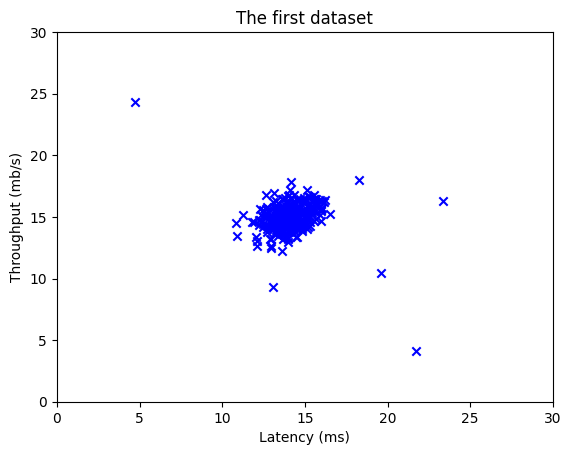

In [9]:
## Create a scatter plot of the data. To change the markers to blue "x", 
# we used the 'marker' and 'c' parameters 
plt.scatter(X_train[:, 0], X_train[:, 1], marker = 'x', c = 'b') 

# Set the title 
plt.title("The first dataset") 

#Set the y-axis label 
plt.ylabel('Throughput (mb/s)') 

# Set the x-axis label 
plt.xlabel('Latency (ms)') 

# Set axis range 
plt.axis([0, 30, 0, 30])
plt.show()

## 2.3 Gaussian distribution 

To perform anamoly detection, we first need to fit a model to the data's distribution 
* Given a training set $\{x^{(1)}, ..., x^{(m)}\}$ you want to estimate the Gaussian distribution for each
of the features $x_i$. 

* Recall that the Gaussian distribution is given by

   $$ p(x ; \mu,\sigma ^2) = \frac{1}{\sqrt{2 \pi \sigma ^2}}\exp^{ - \frac{(x - \mu)^2}{2 \sigma ^2} }$$

   where $\mu$ is the mean and $\sigma^2$ is the variance.
   
* For each feature $i = 1\ldots n$, you need to find parameters $\mu_i$ and $\sigma_i^2$ that fit the data in the $i$-th dimension $\{x_i^{(1)}, ..., x_i^{(m)}\}$ (the $i$-th dimension of each example).

In [10]:
def estimate_gaussian(X): 
    m,n = X.shape 

    mu = (1/m) * np.sum(X, axis = 0) 

    var = (1/m) * np.sum((X - mu)**2, axis = 0) 

    return mu, var

In [12]:
mu, var = estimate_gaussian(X_train)

print("Mean of each feature:", mu) 
print("Variance of each feature:", var)

Mean of each feature: [14.11222578 14.99771051]
Variance of each feature: [1.83263141 1.70974533]


In [17]:
def multivariate_gaussian(X, mu, var): 
    """
    Computes the probability density function of the examples X under the multivariate gaussian 
    distribution with parameters mu and x. If var is a matrix, it is treated as the covariance matrix. 
    If var is a vector, it is treated as the var values as the variance in each dimension (a diagonal 
    covariance matrix) 
    """

    k = len(mu) 

    if var.ndim == 1: 
        var = np.diag(var) 

    X = X - mu 
    p = (2*np.pi) **(-k/2) * np.linalg.det(var)**(-0.5) * \
        np.exp(-0.5 * np.sum(np.matmul(X, np.linalg.pinv(var)) * X, axis = 1))

    return p

In [20]:
p = multivariate_gaussian(X_train, mu, var)

## 2.3.2 Selecting the threshold $\epsilon$

Now that you have estimated the Gaussian parameters, you can investigate which examples have a vary high probability given this distribution and which examples have a very low probability: 
* The low probability examples are more likely to be the anomalies in our dataset
* One way to determine which examples are anomalies is to select a threshold based on cross validation set.

* For this, we will use a cross validation set
$\{(x_{\rm cv}^{(1)}, y_{\rm cv}^{(1)}),\ldots, (x_{\rm cv}^{(m_{\rm cv})}, y_{\rm cv}^{(m_{\rm cv})})\}$, where the label $y=1$ corresponds to an anomalous example, and $y=0$ corresponds to a normal example. 
* For each cross validation example, we will compute $p(x_{\rm cv}^{(i)})$. The vector of all of these probabilities $p(x_{\rm cv}^{(1)}), \ldots, p(x_{\rm cv}^{(m_{\rm cv})})$ is passed to `select_threshold` in the vector `p_val`. 
* The corresponding labels $y_{\rm cv}^{(1)}, \ldots, y_{\rm cv}^{(m_{\rm cv})}$ are passed to the same function in the vector `y_val`.

In the code `select_threshold`, there is already a loop that try many different values of $\varepsilon$ and select the best $\varepsilon$ based on the $F_1$ score.

* Recall that if an example x has a low probability $p(x) < \varepsilon$, then it is classified as an anomaly.
* Then, you can compute precision and recall by: 
   $$\begin{aligned}
   prec&=&\frac{tp}{tp+fp}\\
   rec&=&\frac{tp}{tp+fn},
   \end{aligned}$$ where
    * $tp$ is the number of true positives: the ground truth label says it’s an anomaly and our algorithm correctly classified it as an anomaly.
    * $fp$ is the number of false positives: the ground truth label says it’s not an anomaly, but our algorithm incorrectly classified it as an anomaly.
    * $fn$ is the number of false negatives: the ground truth label says it’s an anomaly, but our algorithm incorrectly classified it as not being anomalous.

  * The $F_1$ score is computed using precision ($prec$) and recall ($rec$) as follows:
    $$F_1 = \frac{2\cdot prec \cdot rec}{prec + rec}$$

* Precision: Out of all predicted values, how many were actually positive?
  * You want high precision when false positives are costly or harmful
    * Examples:
      * Spam detection, medical diagnosis for a rare but harmful condition, fraud detection
     
  * You want high recall when missing true positives is very costly
   
    * Examples:
      * Cancer screening, detecting security breaches, search engines
* Recall: Out of all actuall positives, how many did we correctly predicted as positive?

In [36]:
def select_threshold(y_val, p_val): 
    """
    Finds the best threshold to use for selecting outliers 
    based on the results from validation set (p_val) and the ground_truth(y_val) 

        Args:
        y_val (ndarray): Ground truth on validation set
        p_val (ndarray): Results on validation set
        
    Returns:
        epsilon (float): Threshold chosen 
        F1 (float):      F1 score by choosing epsilon as threshold
    """ 

    best_epsilon = 0
    best_F1 = 0 
    F1 = 0

    step_size = (max(p_val) - min(p_val)) / 1000

    for epsilon in np.arange(min(p_val), max(p_val), step_size): 

        predictions = (p_val < epsilon) 

        tp = np.sum((predictions == 1) & (y_val == 1)) 
        fp = np.sum((predictions == 1) & (y_val == 0)) 
        fn = np.sum((predictions == 0) & (y_val == 1)) 

        if tp + fp == 0 or tp + fn == 0: 
            F1 = 0
            continue 

        prec = tp / (tp + fp)
        rec = tp / (tp + fn)

        if prec + rec == 0: 
            F1 = 0
        else: 
            F1 = (2 * prec * rec) / (prec + rec) 

        if F1 > best_F1: 
            best_F1 = F1 
            best_epsilon = epsilon 

    return best_epsilon, best_F1

In [37]:
p_val = multivariate_gaussian(X_val, mu, var) 
epsilon, F1 = select_threshold(y_val, p_val)

print('Best epsilon found using cross validation: %e' %epsilon) 
print('Best F1 on Cross Validation Set: %f' %F1) 

Best epsilon found using cross validation: 8.990853e-05
Best F1 on Cross Validation Set: 0.875000


In [39]:
# Fine the outliers in the training set 
outliers = p < epsilon 
outliers

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

## 2.4 - High dimensional dataset

Now, we will run the anomaly detection algorithm that you implemented on a more realistic and much harder dataset 

In this dataset, each example is described by 11 featurees, capturing many more properties of your compute servers. 

In [40]:
def load_data_multi(): 
    X = np.load("X_part2.npy") 
    X_val = np.load("X_val_part2.npy") 
    y_val = np.load("y_val_part2.npy") 

    return X, X_val, y_val

In [41]:
X_train_high, X_val_high, y_val_high = load_data_multi()

In [42]:
print('The shape of X_train_high is', X_train_high.shape)
print('The shape of X_val_high is', X_val_high.shape)
print('The shape of y_val_high is', y_val_high.shape)

The shape of X_train_high is (1000, 11)
The shape of X_val_high is (100, 11)
The shape of y_val_high is (100,)


In [43]:
mu_high, var_high = estimate_gaussian(X_train_high) 

p_high = multivariate_gaussian(X_train_high, mu_high, var_high) 

p_val_high = multivariate_gaussian(X_val_high, mu_high, var_high) 

epsilon_high, F1_high = select_threshold(y_val_high, p_val_high) 

print('Best epsilon found using cross-validation: %e'% epsilon_high)
print('Best F1 on Cross Validation Set:  %f'% F1_high)
print('# Anomalies found: %d'% sum(p_high < epsilon_high))

Best epsilon found using cross-validation: 1.377229e-18
Best F1 on Cross Validation Set:  0.615385
# Anomalies found: 117
